# M1-B1 — Réentraînement Pyrenex Crédit (template)

**Objectif** : reproduire et challenger la baseline `pyrenex-risk-v1` sur le nouveau dataset Lending Club.

**Compétence visée** : C5 — imiter.

## 0. Setup

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
DATA_DIR = Path('../data')

## 1. Comprendre la baseline `pyrenex-risk-v1`

| Métrique | Baseline 2017 (Pyrenex-risk-v1) 
|---|---|
| F1 macro (holdout) | 0.5018 |
| F1 défaut | n/d |
| ROC-AUC | 0.7296 |
| Recall défaut | 0.05 |

## 2. EDA du nouveau dataset

Au moins 3 visualisations + un paragraphe sur ce qui diffère du dataset 2017.

In [2]:
df = pd.read_csv(DATA_DIR / 'lending_club_train.csv')
df_2017 = pd.read_csv(DATA_DIR / 'lending_club_2017_subset.csv')

print(df.head(5)) # les 5 première lignes
print(df.dtypes) # le type de chaque colonne
print(df.isnull().sum()) # valeurs manquantes
df.describe()

   loan_amnt       term  int_rate  installment grade emp_length  \
0       5700  36 months      6.71       175.24     A    3 years   
1       8700  36 months     11.83       288.26     C    3 years   
2       7900  36 months     11.25       259.57     C    5 years   
3      35800  36 months      9.61      1148.62     B    3 years   
4      16000  60 months     14.43       375.87     C    8 years   

  home_ownership  annual_inc verification_status             purpose    dti  \
0       MORTGAGE       38900        Not Verified      small_business  17.92   
1           RENT       51400            Verified    home_improvement  21.26   
2           RENT       38900            Verified  debt_consolidation  13.56   
3       MORTGAGE       82900            Verified         credit_card  29.99   
4       MORTGAGE       32700        Not Verified    home_improvement  17.98   

   delinq_2yrs  fico_range_low  revol_util loan_status  
0            0             738        78.1  Fully Paid  
1       

,loan_amnt,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,revol_util
count,24000.000000,24000.000000,24000.000000,24000.00000,24000.000000,24000.000000,24000.000000,23609.000000
mean,13868.137500,12.689344,422.829608,77199.66250,18.027940,0.300000,706.830042,50.003910
std,7778.506846,4.416913,251.819246,46254.54815,8.418299,0.551071,26.137641,20.406427
min,1500.000000,5.000000,39.990000,12000.00000,0.820000,0.000000,614.000000,1.600000
25%,8300.000000,9.810000,242.137500,45700.00000,11.820000,0.000000,689.000000,34.600000
50%,12000.000000,12.170000,360.575000,66200.00000,16.770000,0.000000,706.000000,50.000000
75%,17400.000000,15.060000,535.472500,96000.00000,22.800000,1.000000,724.000000,65.400000
max,40000.000000,30.000000,1662.330000,500000.00000,50.000000,5.000000,782.000000,99.100000


In [3]:
# Schéma vs basline => même colonnes que l'ancien dataset
cols_2025 = set(df.columns)
cols_2017 = set(df_2017.columns)

print("=== SCHEMA ===")
print(f"Colonnes en plus vs baseline : {cols_2025 - cols_2017}")
print(f"Colonnes en moins vs baseline : {cols_2017 - cols_2025}")

print("=== VOLUME ===")
print(f"2017 : {df_2017.shape[0]} lignes x {df_2017.shape[1]} colonnes")
print(f"2025 : {df.shape[0]} lignes x {df.shape[1]} colonnes")

print("=== DESEQUILIBRE ===")
target_2017 = (df_2017["loan_status"] == "Charged Off").mean()
target = (df["loan_status"] == "Charged Off").mean()
print(f"Défaut 2017 : {target_2017*100:.1f}")
print(f"Défaut 2025 : {target*100:.1f}")

=== SCHEMA ===
Colonnes en plus vs baseline : set()
Colonnes en moins vs baseline : set()
=== VOLUME ===
2017 : 12000 lignes x 15 colonnes
2025 : 24000 lignes x 15 colonnes
=== DESEQUILIBRE ===
Défaut 2017 : 14.8
Défaut 2025 : 18.4


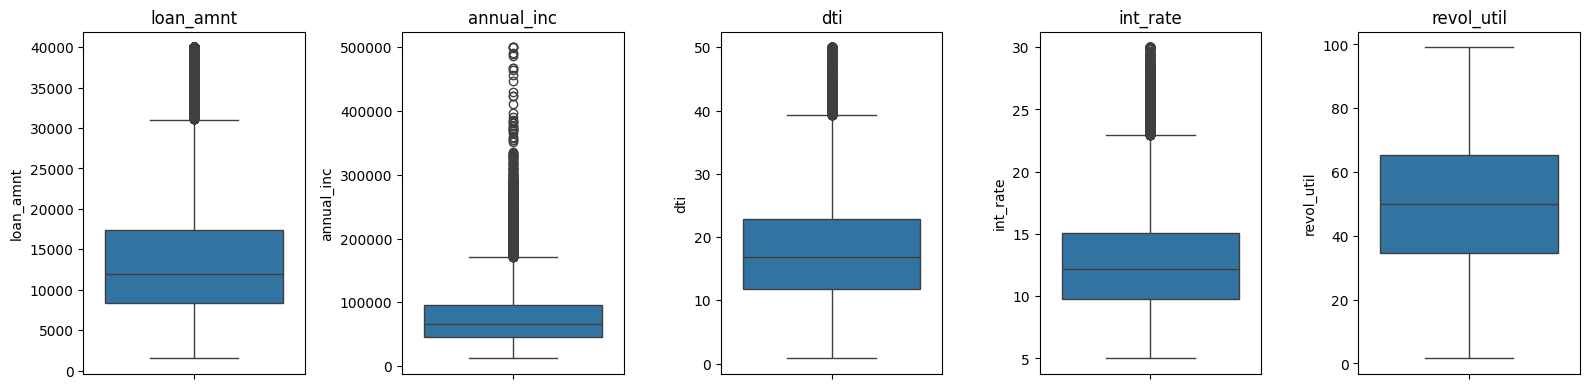

In [4]:
# Détection des anomalies
df.isna().mean().sort_values(ascending=False).head(10) # le taux de manquants par colonne
cols_num = ["loan_amnt", "annual_inc", "dti", "int_rate", "revol_util"]

fig, axes = plt.subplots(1, len(cols_num), figsize=(16,4))
for ax, col in zip(axes, cols_num):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

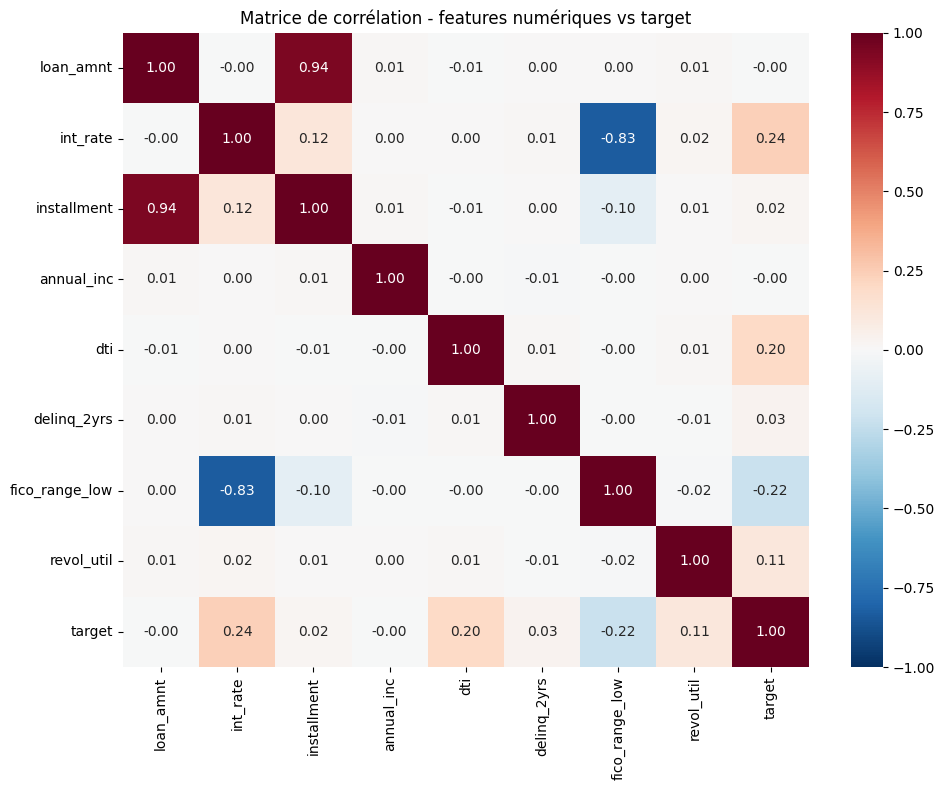

Corrélation avec target
int_rate          0.237466
dti               0.201684
revol_util        0.111370
delinq_2yrs       0.032225
installment       0.016078
loan_amnt        -0.002425
annual_inc       -0.003726
fico_range_low   -0.221225
Name: target, dtype: float64


In [5]:
# Corrélations clés
df["target"] = (df["loan_status"] == "Charged Off").astype(int)

cols_num = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "delinq_2yrs",
           "fico_range_low", "revol_util", "target"
           ]
fig, ax = plt.subplots(figsize=(10,8))
corr_matrix = df[cols_num].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Matrice de corrélation - features numériques vs target")
plt.tight_layout()
plt.show()

print("Corrélation avec target")
print(corr_matrix["target"].drop("target").sort_values(ascending=False))

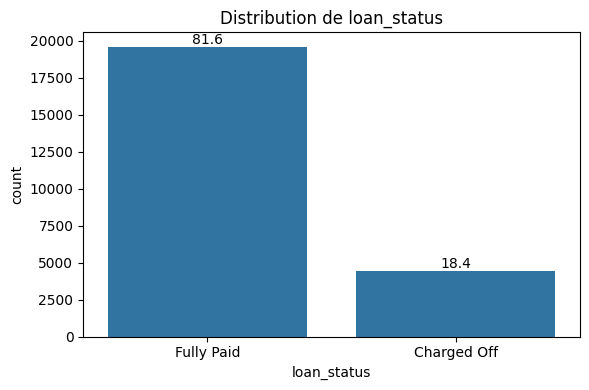

In [6]:
# Déséquilibre des classes
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(x="loan_status", data=df, ax=ax)
ax.set_title("Distribution de loan_status")

total = len(df)
for p in ax.patches:
    pct = f"{100 * p.get_height() / total:.1f}"
    ax.annotate(pct, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 4bis. Le score est-il stable ?

> Avant de comparer deux modèles ou de défendre un chiffre devant Pyrenex, vérifie une chose : **est-ce que ton F1 dépend du découpage train/test ?** Si le score varie déjà beaucoup en changeant juste la `random_state` du split, un gain de +0.005 entre deux modèles est probablement du bruit, pas un vrai progrès.

Lance la boucle ci-dessous avec le modèle entraîné en section 4. Si l'écart entre seeds dépasse l'écart entre tes deux jeux d'hyperparamètres, il faudra passer à la validation croisée (qu'on verra en M2).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

# TODO : adapte aux noms de tes variables (X, y, et le modèle de la section 4)
scores = []
for seed in [0, 1, 42, 100, 2024]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=seed
    )
    model = ...  # ré-instancie le même modèle qu'en section 4
    model.fit(X_tr, y_tr)
    f1 = f1_score(y_te, model.predict(X_te), average='macro')
    scores.append(f1)
    print(f"seed={seed:>4} → F1 macro = {f1:.3f}")

print(f"\nÉcart min-max : {max(scores) - min(scores):.3f}")

**Interprétation** :
- Écart min-max < 0.01 → ton score est stable, tu peux comparer deux modèles sereinement.
- Écart min-max > 0.02 → tes scores sont bruités par le découpage. Un gain inférieur à cet écart entre deux modèles n'est **pas significatif**, c'est probablement de la chance.

> Pour aller plus loin (on verra en M2) : `cross_val_score` fait ce travail proprement en 1 ligne, sur k folds, et te donne moyenne ± écart-type.

## ⭐ Mission étoile optionnelle

Variante A : Gradient Boosting + SHAP. Variante B : Fine-tuning SLM sur `purpose`.